### IMPORTING NECESSARY LIBRARIES

In [2]:
import pandas as pd  # importing pandas for handling dataframes
import numpy as np  # importing numpy for numerical operations
from scipy.sparse import csr_matrix  # importing csr_matrix for creating sparse matrices
from sklearn.preprocessing import LabelEncoder, normalize  # importing LabelEncoder for encoding labels, normalize for normalizing data
from tqdm import tqdm  # importing tqdm for showing progress bars
import warnings  # importing warnings for managing warning messages
import matplotlib.pyplot as plt  # importing matplotlib for creating plots
import seaborn as sns  # importing seaborn for advanced data visualization
import random  # importing random for generating random values
from collections import Counter, defaultdict  # importing Counter for counting elements, defaultdict for creating default dictionaries

### STEP 1: SETUP & DATA LOADING

In [6]:
np.random.seed(42)  # setting numpy random seed for reproducibility
random.seed(42)  # setting random module seed for reproducibility

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')  # ignoring warning messages for cleaner output
# Set plot style
sns.set_style("whitegrid")  # setting seaborn plot style to whitegrid

print("Step 1: Loading data...")  # printing message for starting data loading
try:
    books = pd.read_csv("books.csv")  # loading books dataset from CSV file
    tags = pd.read_csv("tags.csv")  # loading tags dataset from CSV file
    book_tags = pd.read_csv("book_tags.csv")  # loading book_tags dataset from CSV file
    to_read = pd.read_csv("to_read.csv")  # loading to_read dataset from CSV file
    print("Data loaded successfully.")  # printing success message after loading data
except FileNotFoundError as e:  # catching file not found error
    print(f"Error: {e}. Please ensure all CSV files are in the correct directory.")  # printing error message
    raise SystemExit  # stopping program execution if files are missing

Step 1: Loading data...
Data loaded successfully.


### STEP 2: EXPLORATORY DATA ANALYSIS (EDA)


Step 2: Performing Exploratory Data Analysis on raw data...

--- Raw Dataset Statistics ---
Number of unique users: 48,871
Number of unique books: 9,986
Number of unique tags: 34,252
Total 'to-read' interactions: 912,705


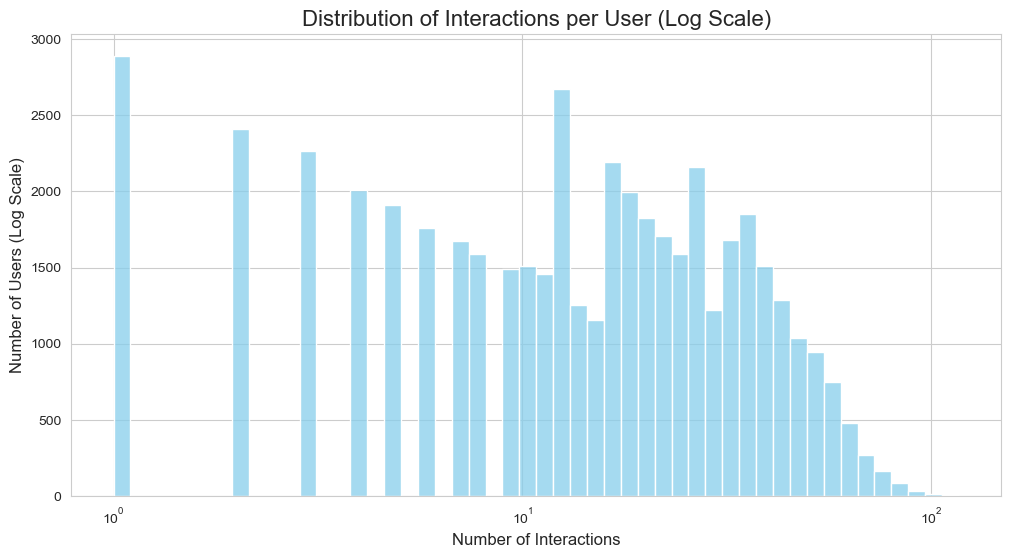

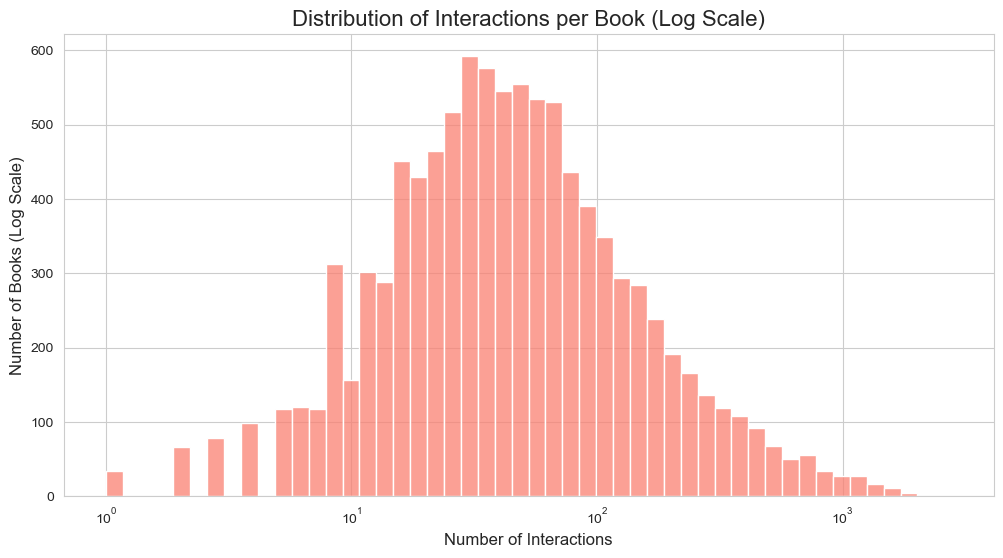

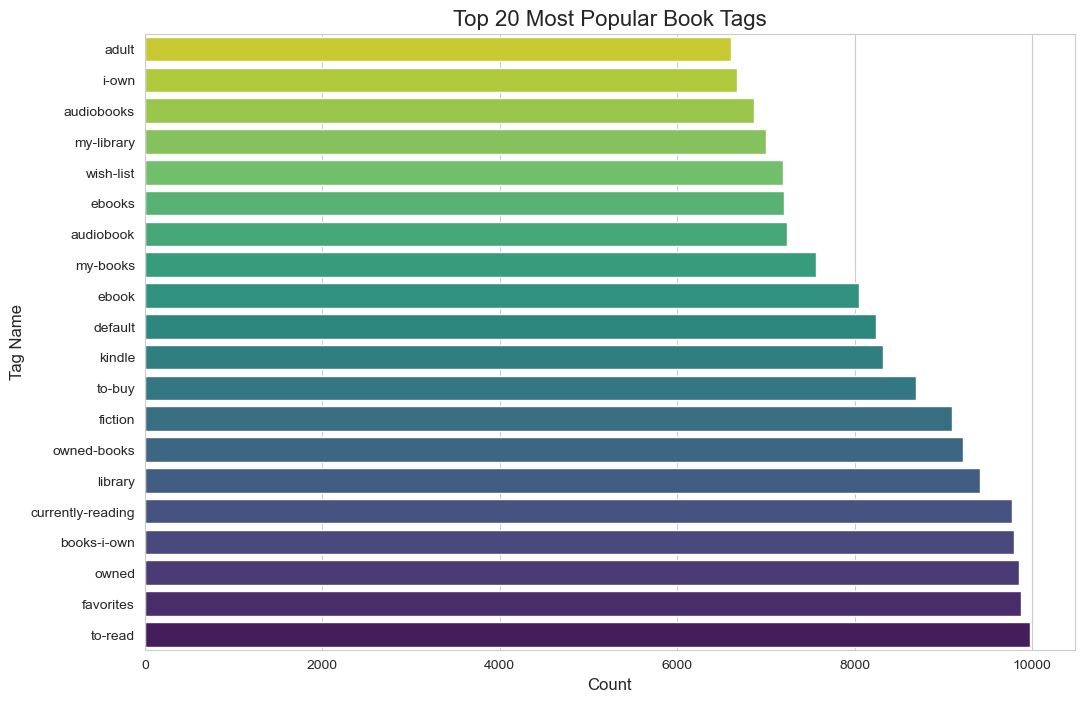

In [8]:
print("\nStep 2: Performing Exploratory Data Analysis on raw data...")  # printing step info for EDA process

n_users = to_read['user_id'].nunique()  # calculating number of unique users
n_books = to_read['book_id'].nunique()  # calculating number of unique books
n_tags = tags['tag_name'].nunique()  # calculating number of unique tags
print(f"\n--- Raw Dataset Statistics ---")  # printing dataset statistics header
print(f"Number of unique users: {n_users:,}")  # printing count of unique users
print(f"Number of unique books: {n_books:,}")  # printing count of unique books
print(f"Number of unique tags: {n_tags:,}")  # printing count of unique tags
print(f"Total 'to-read' interactions: {len(to_read):,}")  # printing total interactions in to_read dataset

user_interaction_counts = to_read['user_id'].value_counts()  # counting interactions per user
plt.figure(figsize=(12, 6))  # creating figure with specific size
sns.histplot(user_interaction_counts, bins=50, log_scale=True, color='skyblue')  # plotting histogram of user interactions
plt.title('Distribution of Interactions per User (Log Scale)', fontsize=16)  # setting plot title
plt.xlabel('Number of Interactions', fontsize=12)  # setting x-axis label
plt.ylabel('Number of Users (Log Scale)', fontsize=12)  # setting y-axis label
plt.show()  # displaying user interaction distribution plot

book_interaction_counts = to_read['book_id'].value_counts()  # counting interactions per book
plt.figure(figsize=(12, 6))  # creating figure with specific size
sns.histplot(book_interaction_counts, bins=50, log_scale=True, color='salmon')  # plotting histogram of book interactions
plt.title('Distribution of Interactions per Book (Log Scale)', fontsize=16)  # setting plot title
plt.xlabel('Number of Interactions', fontsize=12)  # setting x-axis label
plt.ylabel('Number of Books (Log Scale)', fontsize=12)  # setting y-axis label
plt.show()  # displaying book interaction distribution plot

merged_tags_eda = book_tags.merge(tags, on='tag_id', how='left')  # merging book_tags with tags for analysis
top_tags = merged_tags_eda['tag_name'].value_counts().head(20)  # selecting top 20 most frequent tags
plt.figure(figsize=(12, 8))  # creating figure with specific size
sns.barplot(x=top_tags.values, y=top_tags.index, palette='viridis')  # plotting bar chart of top 20 tags
plt.title('Top 20 Most Popular Book Tags', fontsize=16)  # setting plot title
plt.xlabel('Count', fontsize=12)  # setting x-axis label
plt.ylabel('Tag Name', fontsize=12)  # setting y-axis label
plt.gca().invert_yaxis()  # inverting y-axis to show highest values on top
plt.show()  # displaying top tags bar plot

### STEP 3: DATA PRE-PROCESSING & FEATURE ENGINEERING

In [11]:
print("\nStep 3: Pre-processing and merging data...")  # printing step info for preprocessing and merging

# --- Engineering 'aspects' feature from top 10 tags per book ---
print("  - Engineering 'aspects' feature from top 10 tags per book...")  # printing progress for aspects engineering
book_tags = book_tags.rename(columns={'goodreads_book_id': 'book_id'})  # renaming goodreads_book_id column to book_id
book_tags_with_names = book_tags.merge(tags, on='tag_id', how='left')  # merging book_tags with tags to get tag names
book_tags_with_names['rank'] = book_tags_with_names.groupby('book_id')['count'].rank(method='first', ascending=False)  # ranking tags per book by count
top_book_tags = book_tags_with_names[book_tags_with_names['rank'] <= 10]  # selecting top 10 tags per book
book_aspects = top_book_tags.groupby('book_id')['tag_name'].apply(list).reset_index()  # grouping top tags as list for each book
book_aspects = book_aspects.rename(columns={'tag_name': 'aspects'})  # renaming tag_name column to aspects

# --- Creating the master DataFrame ---
print("  - Merging all data sources into a single DataFrame...")  # printing progress for merging data sources
books_with_aspects = books.merge(book_aspects, on='book_id', how='left')  # merging books with aspects
books_with_aspects['aspects'] = books_with_aspects['aspects'].apply(lambda d: d if isinstance(d, list) else [])  # ensuring aspects column is list
books_metadata = books_with_aspects[['book_id', 'title', 'authors', 'average_rating', 'ratings_count', 'original_publication_year', 'aspects']]  # selecting relevant metadata columns
df = to_read.merge(books_metadata, on='book_id', how='inner')  # merging to_read with metadata to create main dataframe

# --- Cleaning the merged DataFrame ---
print(f"  - Removing duplicate user-book interactions...")  # printing progress for removing duplicates
initial_rows = len(df)  # storing initial row count
df = df.drop_duplicates(subset=['user_id', 'book_id'])  # dropping duplicate user-book pairs
print(f"    - Removed {initial_rows - len(df)} duplicate rows.")  # printing number of duplicates removed

# --- Filtering data for quality and create implicit ratings ---
print("  - Filtering for data quality (users >= 10 interactions, books >= 20)...")  # printing filtering criteria
user_counts = df['user_id'].value_counts()  # counting interactions per user
book_counts = df['book_id'].value_counts()  # counting interactions per book
df_filtered = df[df['user_id'].isin(user_counts[user_counts >= 10].index)]  # filtering users with at least 10 interactions
df_filtered = df_filtered[df_filtered['book_id'].isin(book_counts[book_counts >= 20].index)]  # filtering books with at least 20 interactions
df_filtered = df_filtered.assign(rating=1)  # assigning implicit rating of 1 for remaining interactions
print(f"    - Interactions before filtering: {len(df):,}")  # printing number of interactions before filtering
print(f"    - Interactions after filtering: {len(df_filtered):,}")  # printing number of interactions after filtering

# --- Saving the cleaned and filtered data for reproducibility ---
print("  - Saving cleaned and filtered data to 'cleaned_and_filtered_book_data.csv'...")  # printing saving progress
df_filtered.to_csv('cleaned_and_filtered_book_data.csv', index=False)  # saving cleaned dataframe to CSV file
print("Pre-processing complete.")  # printing completion message for preprocessing



Step 3: Pre-processing and merging data...
  - Engineering 'aspects' feature from top 10 tags per book...
  - Merging all data sources into a single DataFrame...
  - Removing duplicate user-book interactions...
    - Removed 0 duplicate rows.
  - Filtering for data quality (users >= 10 interactions, books >= 20)...
    - Interactions before filtering: 87,493
    - Interactions after filtering: 2,860
  - Saving cleaned and filtered data to 'cleaned_and_filtered_book_data.csv'...
Pre-processing complete.


### STEP 4: ADVANCE EDA VISUALIZATIONS


Step 4: Creating further EDA visualizations...


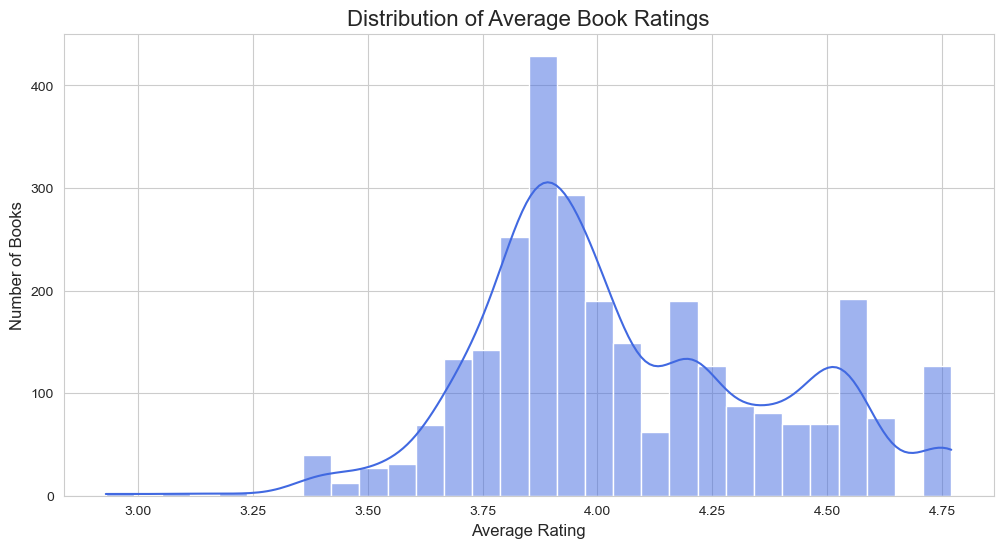

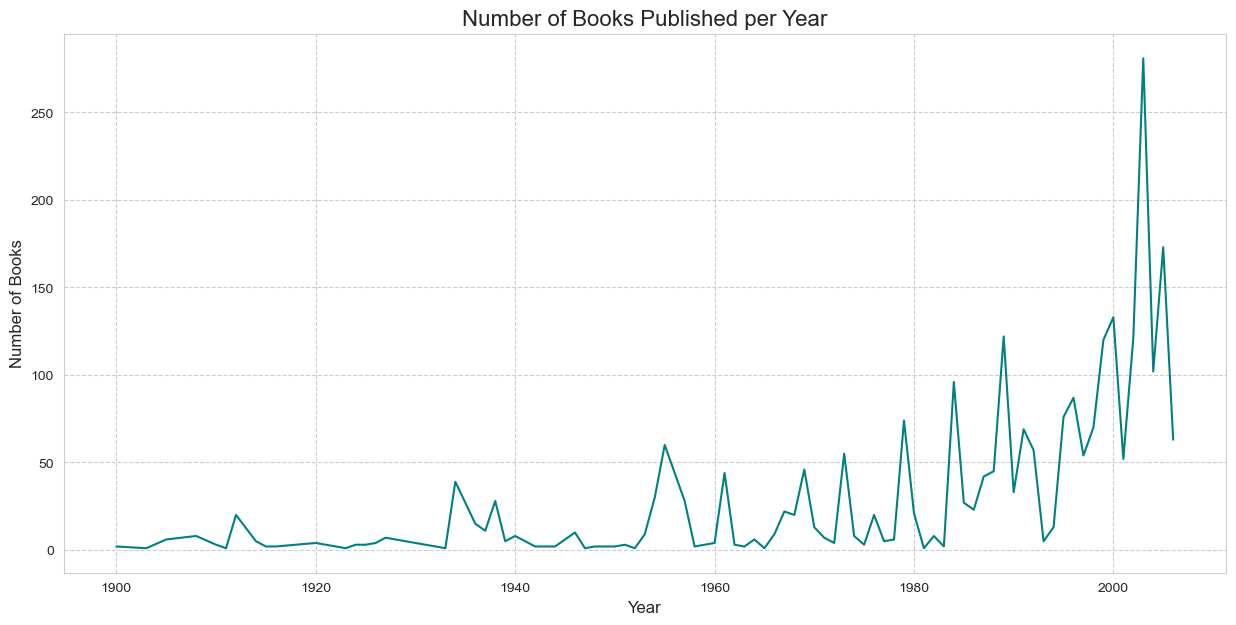

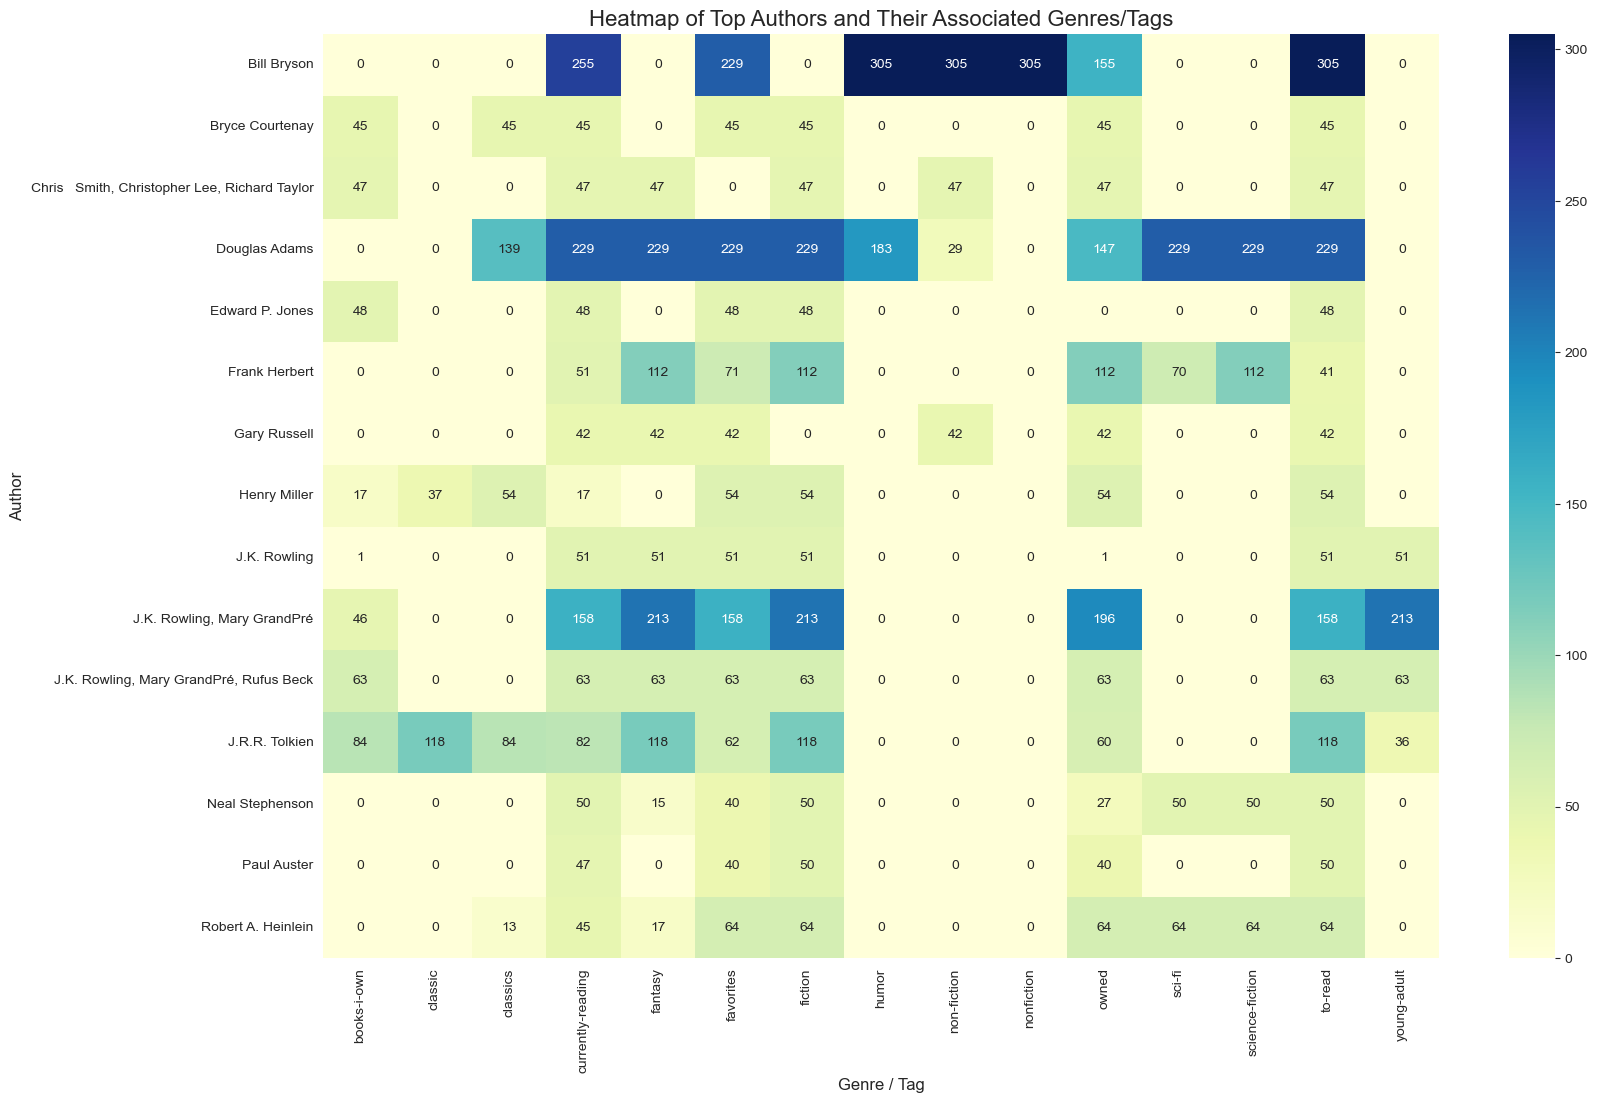

In [14]:
print("\nStep 4: Creating further EDA visualizations...")  # printing step info for further EDA

if not df_filtered.empty:  # checking if filtered dataframe is not empty
    plt.figure(figsize=(12, 6))  # creating figure with specific size
    sns.histplot(df_filtered['average_rating'], bins=30, kde=True, color='royalblue')  # plotting distribution of average ratings
    plt.title('Distribution of Average Book Ratings', fontsize=16)  # setting plot title
    plt.xlabel('Average Rating', fontsize=12)  # setting x-axis label
    plt.ylabel('Number of Books', fontsize=12)  # setting y-axis label
    plt.show()  # displaying rating distribution plot

    publication_years = df_filtered['original_publication_year'].dropna()  # dropping missing publication years
    publication_years = publication_years[(publication_years >= 1900) & (publication_years <= 2020)]  # filtering valid years
    year_counts = publication_years.value_counts().sort_index()  # counting books published per year

    plt.figure(figsize=(15, 7))  # creating figure with specific size
    year_counts.plot(kind='line', color='teal')  # plotting number of books published per year
    plt.title('Number of Books Published per Year', fontsize=16)  # setting plot title
    plt.xlabel('Year', fontsize=12)  # setting x-axis label
    plt.ylabel('Number of Books', fontsize=12)  # setting y-axis label
    plt.grid(True, which='both', linestyle='--')  # adding grid lines
    plt.show()  # displaying publication year trend plot

    author_aspects = df_filtered.explode('aspects')  # exploding aspects list into separate rows
    top_authors = author_aspects['authors'].value_counts().nlargest(15).index  # selecting top 15 authors
    top_aspects = author_aspects['aspects'].value_counts().nlargest(15).index  # selecting top 15 aspects
    filtered_author_aspects = author_aspects[  # filtering rows with top authors and top aspects
        author_aspects['authors'].isin(top_authors) &
        author_aspects['aspects'].isin(top_aspects)
    ]
    author_genre_crosstab = pd.crosstab(filtered_author_aspects['authors'], filtered_author_aspects['aspects'])  # creating crosstab of authors vs aspects

    plt.figure(figsize=(18, 12))  # creating figure with specific size
    sns.heatmap(author_genre_crosstab, cmap='YlGnBu', annot=True, fmt='d')  # plotting heatmap of authors and tags
    plt.title('Heatmap of Top Authors and Their Associated Genres/Tags', fontsize=16)  # setting plot title
    plt.xlabel('Genre / Tag', fontsize=12)  # setting x-axis label
    plt.ylabel('Author', fontsize=12)  # setting y-axis label
    plt.show()  # displaying heatmap plot
else:
    print("No data for further EDA visualizations.")  # printing message if dataframe is empty

### STEP 5: TRAIN-TEST SPLIT

In [20]:
def create_train_test_split(df, test_size=0.2, seed=42):  # defining function to split data into train and test sets
    """Splits interactions into training and testing sets for evaluation (per-user)."""
    # Using pandas groupby.sample with a fixed random_state keeps behavior stable
    test_set = df.groupby('user_id', group_keys=False).apply(lambda g: g.sample(frac=test_size, random_state=seed))  # sampling test data per user
    train_set = df.drop(test_set.index)  # creating train set by dropping test indices
    return train_set, test_set  # returning train and test sets

print("\nStep 5: Creating train and test sets...")  # printing step info for train-test split
train_df, test_df = create_train_test_split(df_filtered)  # splitting filtered dataframe into train and test
print(f"Training set size: {len(train_df):,}")  # printing training set size
print(f"Test set size: {len(test_df):,}")  # printing test set size


Step 5: Creating train and test sets...
Training set size: 2,306
Test set size: 554


### STEP 6: MODEL TRAINING

In [24]:
print("\nStep 6: Building model on the training set...")  # printing step info for model building

df_model = train_df.copy()  # creating copy of training dataframe
user_encoder = LabelEncoder()  # creating label encoder for users
item_encoder = LabelEncoder()  # creating label encoder for items
df_model['user_idx'] = user_encoder.fit_transform(df_model['user_id'])  # encoding user IDs into numeric indices
df_model['item_idx'] = item_encoder.fit_transform(df_model['book_id'])  # encoding book IDs into numeric indices

# Creating mappings for later use 
index_to_book_id = dict(zip(df_model['item_idx'], df_model['book_id']))  # mapping item index to book ID
book_id_to_index = {v: k for k, v in index_to_book_id.items()}  # mapping book ID to item index

# Building the core IBCF similarity matrix 
sparse_matrix = csr_matrix((df_model['rating'], (df_model['item_idx'], df_model['user_idx'])))  # creating sparse item-user matrix
sparse_matrix_normalized = normalize(sparse_matrix, norm='l2', axis=1, copy=True)  # normalizing matrix row-wise with L2 norm
item_similarity = sparse_matrix_normalized.dot(sparse_matrix_normalized.T)  # computing item-item similarity matrix
print("Model built successfully.")  # printing success message after model build


Step 6: Building model on the training set...
Model built successfully.


### PHASE 7: PIPELINE & METRIC DEFINITION

In [27]:
print("\nStep 7: Defining recommendation pipelines and evaluation metrics...")  # printing step info for pipelines and metrics

# --- Recommendationing and Re-ranking Functions (unchanged behavior) ---
def get_ibcf_recommendations(book_id, top_n=50):  # defining function to get IBCF recommendations
    if book_id not in book_id_to_index:  # checking if book exists in mapping
        return pd.DataFrame(columns=['book_id','title','ibcf_score'])  # returning empty DataFrame if not found
    item_idx = book_id_to_index[book_id]  # getting item index for book
    sim_scores = item_similarity[item_idx].toarray().flatten()  # extracting similarity scores for book
    # sort descending, skip self
    top_indices = np.argsort(sim_scores)[::-1][1:top_n+1]  # sorting similarity scores, skipping self
    top_scores = sim_scores[top_indices]  # selecting top similarity scores
    recommended_book_ids = [index_to_book_id.get(i) for i in top_indices if i in index_to_book_id]  # mapping indices back to book IDs
    results = pd.DataFrame({'book_id': recommended_book_ids, 'ibcf_score': top_scores[:len(recommended_book_ids)]})  # creating recommendations dataframe
    results = results.merge(df_model[['book_id', 'title']].drop_duplicates(), on='book_id', how='left')  # merging with titles
    return results[['book_id', 'title', 'ibcf_score']]  # returning final dataframe

def mmr_re_rank(base_recs, lambda_param=0.5, top_n=10):  # defining MMR re-ranking function
    """MMR re-ranking (keeps your original behavior: start with top candidate)."""
    if base_recs.empty:  # checking if recommendations are empty
        return pd.DataFrame(columns=base_recs.columns)  # returning empty DataFrame

    candidates = base_recs.copy().reset_index(drop=True)  # copying base recommendations
    cand_indices = candidates['book_id'].map(book_id_to_index).values  # mapping book IDs to indices
    # Build similarity submatrix; fall back if any NaNs
    sim_subset = item_similarity[np.ix_(cand_indices, cand_indices)].toarray()  # creating similarity submatrix

    # NOTE: preserve your original strategy: start with the highest relevance
    selected = [0]  # starting with top candidate
    max_div = np.zeros(len(candidates))  # initializing max diversity tracker

    while len(selected) < min(top_n, len(candidates)):  # iterating until top_n is reached
        # update diversity wrt the last selected
        new_div_scores = sim_subset[:, selected[-1]]  # getting similarity to last selected
        max_div = np.maximum(max_div, new_div_scores)  # updating diversity tracker

        # compute MMR for all (mask selected)
        relevance = candidates['ibcf_score'].values  # using ibcf_score as relevance
        mmr_scores = lambda_param * relevance - (1 - lambda_param) * max_div  # computing MMR scores
        mmr_scores[selected] = -np.inf  # excluding already selected items

        best_idx = int(np.argmax(mmr_scores))  # selecting best index
        if not np.isfinite(mmr_scores[best_idx]):  # breaking if invalid score
            break
        selected.append(best_idx)  # adding best candidate to selection

    return candidates.iloc[selected].reset_index(drop=True)  # returning re-ranked recommendations

def apply_popularity_boost(recs, alpha=0.5):  # defining popularity boost function
    """Popularity mix with zero-division guard (behavior preserved for normal ranges)."""
    if recs.empty:  # checking if recommendations are empty
        return pd.DataFrame(columns=recs.columns)  # returning empty DataFrame
    pop_data = df_model[['book_id', 'ratings_count']].drop_duplicates().set_index('book_id')  # extracting popularity data
    recs = recs.join(pop_data, on='book_id')  # joining popularity info
    # guard against None/NaN
    recs['ratings_count'] = recs['ratings_count'].fillna(0)  # filling missing popularity values
    rmin, rmax = recs['ratings_count'].min(), recs['ratings_count'].max()  # getting min and max popularity
    denom = (rmax - rmin) if (rmax > rmin) else 1.0  # preventing division by zero
    recs['pop_normalized'] = (recs['ratings_count'] - rmin) / denom  # normalizing popularity
    recs['pop_score'] = (1 - alpha) * recs['ibcf_score'] + alpha * recs['pop_normalized']  # mixing IBCF and popularity
    return recs.sort_values('pop_score', ascending=False).drop(columns=['ratings_count', 'pop_normalized', 'pop_score'])  # returning boosted recs

def xquad_re_rank(recs, lambda_param=0.7, top_n=10):  # defining xQuAD re-ranking function
    """Your original xQuAD-style aspect-count re-rank (unchanged scoring form)."""
    if recs.empty:  # checking if recommendations are empty
        return pd.DataFrame(columns=recs.columns)  # returning empty DataFrame

    recs = recs.copy().reset_index(drop=True)  # copying recommendations
    if 'aspects' not in recs.columns:  # ensuring aspects column exists
        recs['aspects'] = [[] for _ in range(len(recs))]
    recs['aspects'] = recs['aspects'].apply(lambda a: a if isinstance(a, list) else [])  # ensuring aspects are lists

    selected = []  # initializing selected recommendations
    covered_aspects = set()  # tracking covered aspects

    while len(selected) < min(top_n, len(recs)):  # iterating until top_n reached
        aspect_gains = recs['aspects'].apply(lambda asp: len(set(asp) - covered_aspects)).values  # computing aspect gains
        relevance = recs['ibcf_score'].values  # using ibcf_score as relevance
        xquad_scores = lambda_param * relevance + (1 - lambda_param) * aspect_gains  # computing xQuAD scores

        if selected:  # masking already selected
            xquad_scores[selected] = -np.inf

        best_idx = int(np.argmax(xquad_scores))  # selecting best index
        if not np.isfinite(xquad_scores[best_idx]):  # breaking if invalid score
            break

        selected.append(best_idx)  # adding best recommendation
        covered_aspects.update(recs.loc[best_idx, 'aspects'])  # updating covered aspects

    return recs.iloc[selected].reset_index(drop=True)  # returning re-ranked recommendations

# --- Pipelines to compare ---
def pipeline_ibcf_only(book_id, top_n=10):  # defining simple IBCF pipeline
    return get_ibcf_recommendations(book_id, top_n=top_n)  # returning raw IBCF recommendations

def pipeline_full(book_id, top_n=10):  # defining full pipeline with re-ranking
    ibcf_recs = get_ibcf_recommendations(book_id, top_n=50)  # generating base IBCF recommendations
    if ibcf_recs.empty:  # checking if empty
        return pd.DataFrame(columns=['book_id','title','ibcf_score'])  # returning empty DataFrame
    mmr_recs = mmr_re_rank(ibcf_recs, lambda_param=0.85, top_n=20)  # applying MMR re-ranking
    pop_recs = apply_popularity_boost(mmr_recs, alpha=0.1)  # applying popularity boost
    aspect_data = df_model[['book_id', 'aspects']].drop_duplicates(subset=['book_id'])  # extracting aspect data
    pop_recs_with_aspects = pop_recs.merge(aspect_data, on='book_id', how='left')  # merging aspects with recs
    final_recs = xquad_re_rank(pop_recs_with_aspects, lambda_param=0.85, top_n=top_n)  # applying xQuAD re-ranking
    return final_recs[['book_id', 'title', 'ibcf_score']]  # returning final recommendations

# --- Evaluating Metric Functions (main table preserved) ---
def precision_recall_at_k(recommendations, ground_truth, k):  # defining precision and recall calculation
    rec_k = recommendations['book_id'].head(k).tolist()  # taking top-k recommendations
    gt_set = set(ground_truth)  # converting ground truth to set
    hits = len(set(rec_k) & gt_set)  # counting hits
    precision = hits / k if k > 0 else 0.0  # computing precision
    recall = hits / len(gt_set) if len(gt_set) > 0 else 0.0  # computing recall
    return precision, recall  # returning precision and recall

def intra_list_similarity(recommendations, similarity_matrix, k):  # defining intra-list similarity
    """Average pairwise similarity among top-k (your original 'ILS': lower is better)."""
    rec_ids = recommendations['book_id'].head(k).tolist()  # taking top-k recommendations
    if len(rec_ids) < 2:  # returning 0 if fewer than 2
        return 0.0
    rec_indices = [book_id_to_index[bid] for bid in rec_ids if bid in book_id_to_index]  # mapping to indices
    if len(rec_indices) < 2:  # returning 0 if fewer than 2
        return 0.0
    subset_sim_matrix = similarity_matrix[np.ix_(rec_indices, rec_indices)]  # creating similarity submatrix
    total_similarity = float(np.sum(np.triu(subset_sim_matrix.toarray(), k=1)))  # summing upper triangle similarities
    num_pairs = len(rec_indices) * (len(rec_indices) - 1) / 2  # counting pairs
    return total_similarity / num_pairs if num_pairs > 0 else 0.0  # returning average similarity

def coverage(recommended_items, all_items):  # defining coverage metric
    return (len(recommended_items) / len(all_items)) if len(all_items) > 0 else 0.0  # computing coverage

# --- Supplementary metrics (ADDED; NOT used in main results) ---
def ndcg_at_k(recommendations, ground_truth, k):  # defining NDCG metric
    rec_k = recommendations['book_id'].head(k).tolist()  # taking top-k recommendations
    rel = [1 if b in set(ground_truth) else 0 for b in rec_k]  # assigning relevance
    if not any(rel):  # returning 0 if no relevance
        return 0.0
    dcg = sum(r/np.log2(i+2) for i, r in enumerate(rel))  # computing DCG
    ideal = sorted(rel, reverse=True)  # sorting ideal relevance
    idcg = sum(r/np.log2(i+2) for i, r in enumerate(ideal))  # computing IDCG
    return dcg / (idcg + 1e-12)  # returning normalized DCG

def intra_list_diversity(recommendations, similarity_matrix, k):  # defining ILD metric
    """ILD = 1 - average similarity (for reference only)."""
    ils = intra_list_similarity(recommendations, similarity_matrix, k)  # calculating ILS
    return 1.0 - ils  # returning diversity

# Precomputing popularity for EPC
pop_counts_global = train_df['book_id'].value_counts()  # counting book popularity in training data
pop_prob_global = (pop_counts_global / pop_counts_global.sum()).to_dict()  # converting popularity to probabilities

def epc_at_k(recommendations, k):  # defining EPC metric
    """Expected Popularity Complement (higher => more novel)."""
    rec_k = recommendations['book_id'].head(k).tolist()  # taking top-k recommendations
    probs = [pop_prob_global.get(b, 1e-12) for b in rec_k]  # retrieving popularity probabilities
    return float(np.mean([-np.log2(p) for p in probs])) if probs else 0.0  # returning EPC

print("Pipelines and metrics defined.")  # printing confirmation message


Step 7: Defining recommendation pipelines and evaluation metrics...
Pipelines and metrics defined.


### PHASE 8: EVALUATION

In [30]:
print("\nStep 8: Running evaluation...")  # printing step info for evaluation

ground_truth_map = test_df.groupby('user_id')['book_id'].apply(list).to_dict()  # creating ground truth map of test items
user_history_map = train_df.groupby('user_id')['book_id'].apply(list).to_dict()  # creating history map from training set

models_to_evaluate = {  # defining models to evaluate
    "IBCF Only": pipeline_ibcf_only,
    "Full Pipeline (Tuned)": pipeline_full
}

results_summary = []  # initializing main evaluation summary
supplementary_summary = []  # initializing supplementary metrics summary
k = 10  # setting evaluation cutoff (top-k)

all_results_data = []  # initializing detailed results list
all_recommendations_collection = {model_name: [] for model_name in models_to_evaluate}  # initializing recommendations store

for model_name, pipeline_func in models_to_evaluate.items():  # iterating through models
    print(f"  Evaluating model: {model_name}")  # printing model being evaluated
    all_precisions, all_recalls, all_ils = [], [], []  # initializing metric lists
    all_ndcgs, all_ilds, all_epcs = [], [], []  # initializing supplementary metric lists
    all_recommended_books = set()  # initializing coverage set
    test_users = list(ground_truth_map.keys())  # getting test users

    for user_id in tqdm(test_users, desc=f"  {model_name}"):  # iterating through test users with progress bar
        history = user_history_map.get(user_id, [])  # getting user history
        if not history:  # skipping if no history
            continue
        seed_book_id = history[-1]  # selecting last book as seed
        recs = pipeline_func(seed_book_id, top_n=k)  # generating recommendations
        if recs.empty:  # skipping if no recommendations
            continue

        gt = ground_truth_map.get(user_id, [])  # getting ground truth books
        precision, recall = precision_recall_at_k(recs, gt, k)  # calculating precision and recall
        ils = intra_list_similarity(recs, item_similarity, k)  # calculating intra-list similarity

        # Supplementary (not affecting main table)
        ndcg = ndcg_at_k(recs, gt, k)  # calculating NDCG
        ild = intra_list_diversity(recs, item_similarity, k)  # calculating ILD
        epc = epc_at_k(recs, k)  # calculating EPC

        all_results_data.append({'Model': model_name, 'Precision': precision, 'ILS': ils})  # storing partial results
        all_recommendations_collection[model_name].extend(recs['book_id'].tolist())  # collecting recommendations

        all_precisions.append(precision)  # appending precision
        all_recalls.append(recall)  # appending recall
        all_ils.append(ils)  # appending ILS
        all_ndcgs.append(ndcg)  # appending NDCG
        all_ilds.append(ild)  # appending ILD
        all_epcs.append(epc)  # appending EPC

        all_recommended_books.update(recs['book_id'].tolist())  # updating recommended books set

    avg_precision = float(np.mean(all_precisions)) if all_precisions else 0.0  # computing average precision
    avg_recall = float(np.mean(all_recalls)) if all_recalls else 0.0  # computing average recall
    avg_ils = float(np.mean(all_ils)) if all_ils else 0.0  # computing average ILS
    catalog_coverage = coverage(all_recommended_books, set(df_model['book_id']))  # computing coverage

    results_summary.append({  # appending main evaluation results
        "Model": model_name,
        f"Precision@{k}": avg_precision,
        f"Recall@{k}": avg_recall,
        f"ILS@{k} (Diversity)": avg_ils,  # storing diversity metric
        "Coverage (Novelty)": catalog_coverage
    })

    # Supplementary (not included in main results table)
    supplementary_summary.append({  # appending supplementary metrics
        "Model": model_name,
        f"NDCG@{k}": float(np.mean(all_ndcgs)) if all_ndcgs else 0.0,
        f"ILD@{k}": float(np.mean(all_ilds)) if all_ilds else 0.0,
        f"EPC@{k}": float(np.mean(all_epcs)) if all_epcs else 0.0
    })


Step 8: Running evaluation...
  Evaluating model: IBCF Only


  IBCF Only: 100%|███████████████████████████████████████████████████████████████████| 267/267 [00:02<00:00, 95.20it/s]


  Evaluating model: Full Pipeline (Tuned)


  Full Pipeline (Tuned): 100%|███████████████████████████████████████████████████████| 267/267 [00:10<00:00, 26.63it/s]


### STEP 9: RESULTS DISPLAY

In [33]:
print("\nStep 9: Final Results Summary (UNCHANGED metrics)...")  # printing step info for final results
results_df = pd.DataFrame(results_summary)  # creating DataFrame for main results

print("\n" + "="*80)  # printing separator line
print("                          DISSERTATION RESULTS (Main Table)")  # printing results header
print("="*80)  # printing separator line
print(results_df.to_string(index=False))  # printing results DataFrame without index
print("="*80)  # printing separator line
print("\nAnalysis:")  # printing analysis header
print("- Precision/Recall: Higher is better (accuracy).")  # explaining precision/recall
print("- ILS (Intra-List Similarity): LOWER is better (more diverse recommendations).")  # explaining ILS
print("- Coverage: Higher is better (recommending a wider range of books).")  # explaining coverage

# --- Supplementary metrics (new, does NOT affect main table) ---
supp_df = pd.DataFrame(supplementary_summary)  # creating DataFrame for supplementary metrics
print("\nSupplementary Metrics (for appendix/discussion; does not affect main results):")  # printing supplementary header
print(supp_df.to_string(index=False))  # printing supplementary metrics
print("Notes: NDCG is rank-sensitive; ILD = 1 - ILS; EPC captures novelty vs global popularity.\n")  # explaining supplementary metrics


Step 9: Final Results Summary (UNCHANGED metrics)...

                          DISSERTATION RESULTS (Main Table)
                Model  Precision@10  Recall@10  ILS@10 (Diversity)  Coverage (Novelty)
            IBCF Only      0.005618   0.027466            0.131872              0.9525
Full Pipeline (Tuned)      0.005243   0.025593            0.090907              0.9200

Analysis:
- Precision/Recall: Higher is better (accuracy).
- ILS (Intra-List Similarity): LOWER is better (more diverse recommendations).
- Coverage: Higher is better (recommending a wider range of books).

Supplementary Metrics (for appendix/discussion; does not affect main results):
                Model  NDCG@10   ILD@10   EPC@10
            IBCF Only 0.023129 0.868128 8.814904
Full Pipeline (Tuned) 0.021134 0.909093 8.848688
Notes: NDCG is rank-sensitive; ILD = 1 - ILS; EPC captures novelty vs global popularity.



### STEP 10: VISUALIZE RESULTS


Step 10: Visualizing the evaluation results...


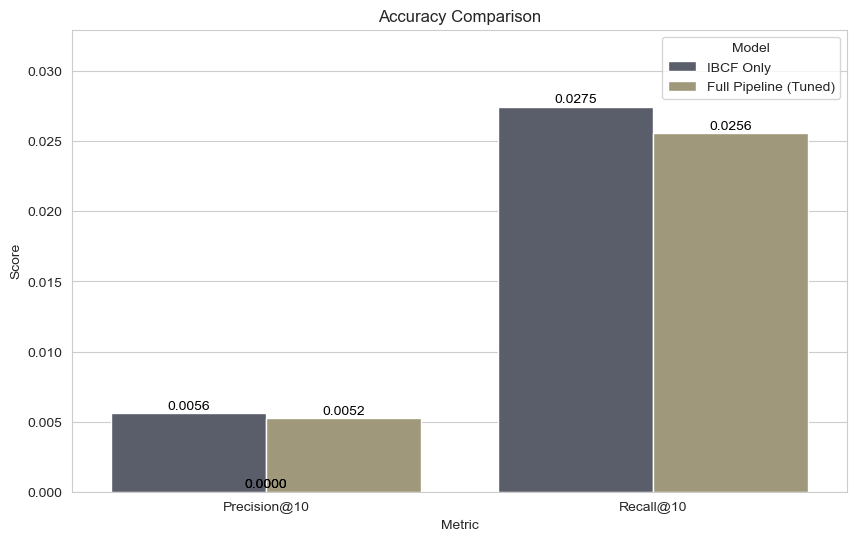

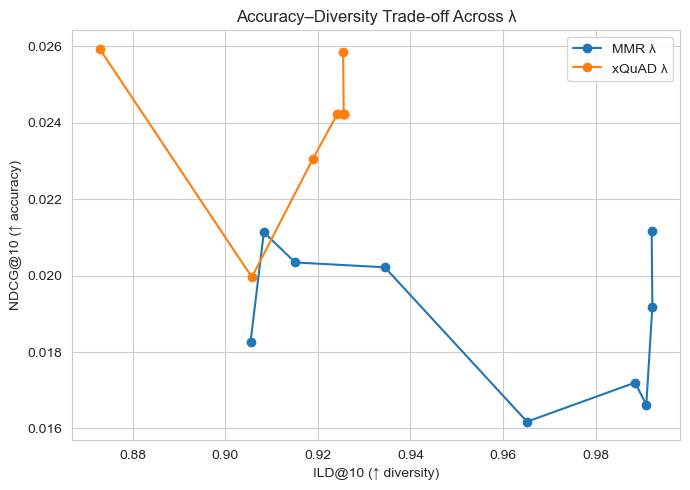

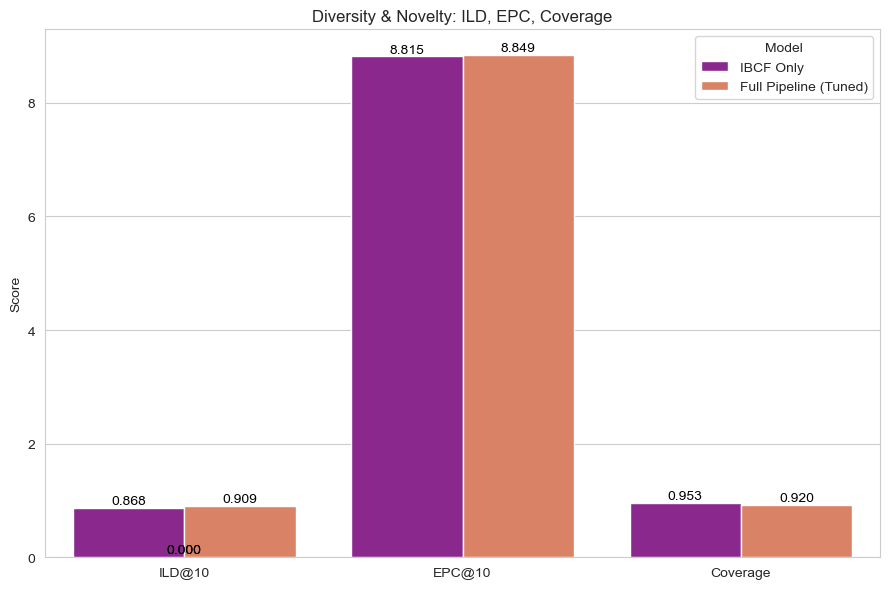

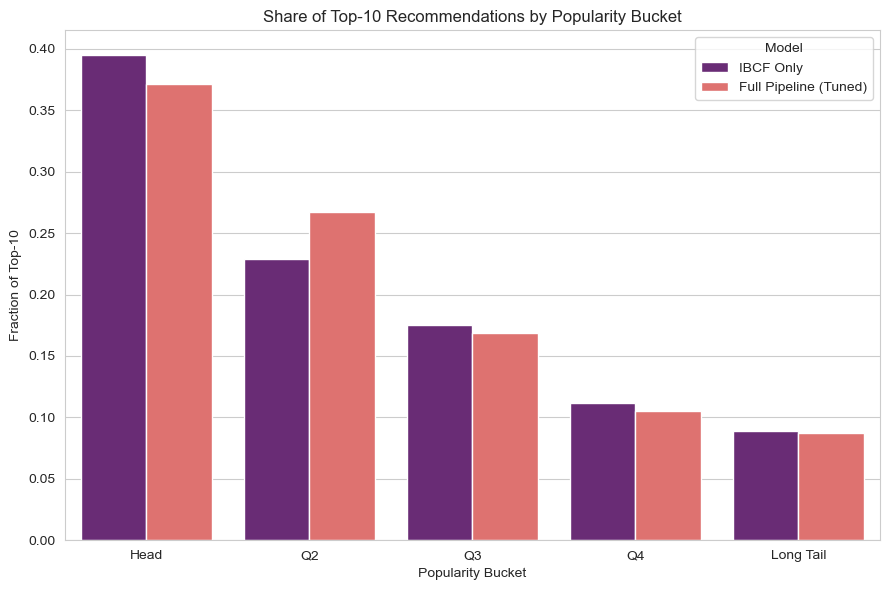

In [39]:
print("\nStep 10: Visualizing the evaluation results...")  # printing step info for visualization

# =====================================
#Figure 1 — Accuracy comparison
# =====================================

if not results_df.empty:  # checking if results dataframe is not empty
    results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')  # reshaping results for plotting

    accuracy_metrics = results_melted[results_melted['Metric'].isin([f'Precision@{k}', f'Recall@{k}'])]  # filtering accuracy metrics
    plt.figure(figsize=(10, 6))  # creating figure for accuracy comparison
    ax = sns.barplot(x='Metric', y='Score', hue='Model', data=accuracy_metrics, palette='cividis')  # plotting bar chart for accuracy
    plt.title('Accuracy Comparison', fontsize=12)  # setting plot title
    plt.ylabel('Score', fontsize=10)  # setting y-axis label
    plt.xlabel('Metric', fontsize=10)  # setting x-axis label
    plt.ylim(0, max(accuracy_metrics['Score']) * 1.2 if len(accuracy_metrics) else 1)  # setting y-axis limits
    for p in ax.patches:  # iterating over bars for annotations
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width()/2., p.get_height()),  # adding value labels
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')
    plt.legend(title='Model')  # showing legend
    plt.show()  # displaying accuracy comparison plot
else:
    print("No results to visualize.")  # printing message if results are empty


# =========================
#Figure 2 — Accuracy vs. Diversity Trade-off (Pareto curve)
# =========================
lambdas = np.linspace(0.0, 1.0, 9)  # creating lambda sweep from 0 to 1
k = 10  # setting top-k
pareto = []  # initializing container for pareto points

def run_with_mmr_lambda(seed_book_id, lam, top_k=k):  # defining runner varying MMR lambda
    ib = get_ibcf_recommendations(seed_book_id, top_n=50)  # generating base IBCF recommendations
    if ib.empty: return pd.DataFrame()  # returning empty if no base recs
    mm = mmr_re_rank(ib, lambda_param=lam, top_n=20)  # applying MMR with lambda
    po = apply_popularity_boost(mm, alpha=0.1)  # applying popularity boost
    asp = df_model[['book_id','aspects']].drop_duplicates('book_id')  # preparing aspect data
    poa = po.merge(asp, on='book_id', how='left')  # joining aspects to recs
    return xquad_re_rank(poa, lambda_param=0.85, top_n=top_k)  # applying xQuAD with fixed lambda

def run_with_xquad_lambda(seed_book_id, lam, top_k=k):  # defining runner varying xQuAD lambda
    ib = get_ibcf_recommendations(seed_book_id, top_n=50)  # generating base IBCF recommendations
    if ib.empty: return pd.DataFrame()  # returning empty if no base recs
    mm = mmr_re_rank(ib, lambda_param=0.85, top_n=20)  # applying MMR with fixed lambda
    po = apply_popularity_boost(mm, alpha=0.1)  # applying popularity boost
    asp = df_model[['book_id','aspects']].drop_duplicates('book_id')  # preparing aspect data
    poa = po.merge(asp, on='book_id', how='left')  # joining aspects to recs
    return xquad_re_rank(poa, lambda_param=lam, top_n=top_k)  # applying xQuAD with lambda

for label, runner in [("MMR λ", run_with_mmr_lambda), ("xQuAD λ", run_with_xquad_lambda)]:  # iterating over runners
    for lam in lambdas:  # iterating over lambda values
        nd_list, ild_list = [], []  # initializing metric collectors
        for u, gt in ground_truth_map.items():  # iterating over users for metrics
            hist = user_history_map.get(u, [])  # getting user history
            if not hist: continue  # skipping if no history
            recs = runner(hist[-1], lam, k)  # generating recommendations with lambda
            if recs.empty: continue  # skipping if empty recs
            nd_list.append(ndcg_at_k(recs, gt, k))  # appending NDCG
            ild_list.append(intra_list_diversity(recs, item_similarity, k))  # appending ILD
        if nd_list:  # checking if any metrics collected
            pareto.append({"Method": label, "λ": lam,  # adding pareto point
                           f"NDCG@{k}": np.mean(nd_list),
                           f"ILD@{k}": np.mean(ild_list)})

pareto_df = pd.DataFrame(pareto)  # converting pareto list to DataFrame

plt.figure(figsize=(7,5))  # creating figure for pareto curve
for name, g in pareto_df.groupby("Method"):  # plotting curve per method
    plt.plot(g[f"ILD@{k}"], g[f"NDCG@{k}"], marker='o', label=name)  # plotting ILD vs NDCG
plt.xlabel(f"ILD@{k} (↑ diversity)")  # setting x-axis label
plt.ylabel(f"NDCG@{k} (↑ accuracy)")  # setting y-axis label
plt.title("Accuracy–Diversity Trade-off Across λ")  # setting plot title
plt.legend()  # showing legend
plt.tight_layout()  # tightening layout
plt.show()  # displaying pareto curve

# ================================================
#Figure 3 — Diversity & Novelty Comparison (grouped bars: ILD, EPC, Coverage)
# ================================================
k = 10  # setting top-k
rows = []  # initializing results container

def eval_model_for_diversity(pipe, label):  # defining helper to evaluate diversity metrics
    ilds, epcs = [], []  # initializing lists for ILD and EPC
    rec_items = set()  # initializing set for recommended items
    for u, gt in ground_truth_map.items():  # iterating over users
        hist = user_history_map.get(u, [])  # getting history
        if not hist: continue  # skipping if no history
        recs = pipe(hist[-1], top_n=k)  # generating top-k recommendations
        if recs.empty: continue  # skipping if empty recs
        ilds.append(intra_list_diversity(recs, item_similarity, k))  # appending ILD
        epcs.append(epc_at_k(recs, k))  # appending EPC
        rec_items.update(recs['book_id'].head(k).tolist())  # updating coverage set
    cov = coverage(rec_items, set(df_model['book_id']))  # computing coverage
    rows.append({"Model": label, f"ILD@{k}": np.mean(ilds) if ilds else 0.0,  # appending results row
                 f"EPC@{k}": np.mean(epcs) if epcs else 0.0,
                 "Coverage": cov})

eval_model_for_diversity(pipeline_ibcf_only, "IBCF Only")  # evaluating IBCF Only
eval_model_for_diversity(pipeline_full, "Full Pipeline (Tuned)")  # evaluating full pipeline

div_df = pd.DataFrame(rows)  # creating DataFrame for diversity results
div_melt = div_df.melt(id_vars="Model", var_name="Metric", value_name="Score")  # melting for plotting

plt.figure(figsize=(9,6))  # creating figure for diversity comparison
ax = sns.barplot(data=div_melt, x="Metric", y="Score", hue="Model", palette="plasma")  # plotting grouped bars
plt.title("Diversity & Novelty: ILD, EPC, Coverage")  # setting plot title
plt.ylabel("Score")  # setting y-axis label
plt.xlabel("")  # clearing x-axis label
for p in ax.patches:  # annotating bars with values
    ax.annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0,5),
                textcoords='offset points')
plt.tight_layout()  # tightening layout
plt.show()  # displaying diversity comparison plot


# ==========================================================
# Figure 4: Popularity-Bucket Exposure (head vs long tail)
# ==========================================================
pop = train_df['book_id'].value_counts()  # counting book frequencies in training
ranks = pop.rank(method='first', ascending=False)  # ranking books by popularity
# 5 buckets: Head to Long Tail
quant = pd.qcut(ranks, q=5, labels=["Head","Q2","Q3","Q4","Long Tail"]).astype(str)  # binning ranks into 5 buckets
pop_bucket = quant.to_dict()  # book_id -> bucket  # converting bucket series to dict

def bucket_share_series(recs, k=10):  # defining helper to compute bucket shares
    xs = recs['book_id'].head(k).map(lambda b: pop_bucket.get(b, "Unknown"))  # mapping recs to buckets
    return xs.value_counts(normalize=True)  # returning normalized counts per bucket

bucket_rows = []  # initializing list for bucket result rows
for model_name, pipe in {"IBCF Only": pipeline_ibcf_only,  # iterating over models
                         "Full Pipeline (Tuned)": pipeline_full}.items():
    agg = Counter(); n = 0  # initializing aggregator and user count
    for u in ground_truth_map:  # iterating over users
        hist = user_history_map.get(u, [])  # getting user history
        if not hist: continue  # skipping if no history
        r = pipe(hist[-1], top_n=10)  # generating top-10 recommendations
        if r.empty: continue  # skipping if empty recs
        agg.update(bucket_share_series(r).to_dict()); n += 1  # accumulating bucket shares and incrementing count
    for b in ["Head","Q2","Q3","Q4","Long Tail"]:  # iterating over buckets
        bucket_rows.append({"Model": model_name, "Bucket": b,  # appending averaged bucket share
                            "Share": agg.get(b,0)/max(n,1)})

bucket_df = pd.DataFrame(bucket_rows)  # creating DataFrame for bucket shares

plt.figure(figsize=(9,6))  # creating figure for popularity bucket exposure
sns.barplot(data=bucket_df, x="Bucket", y="Share", hue="Model", palette="magma")  # plotting bucket share bars
plt.title("Share of Top-10 Recommendations by Popularity Bucket")  # setting plot title
plt.ylabel("Fraction of Top-10")  # setting y-axis label
plt.xlabel("Popularity Bucket")  # setting x-axis label
plt.tight_layout()  # tightening layout
plt.show()  # displaying popularity bucket exposure plot

### STEP 11: STEP-BY-STEP EXAMPLE

In [41]:
print("\nStep 11: Showing a step-by-step example of the pipeline...")  # printing step info for demonstration

#example_book_id = random.choice(df_model['book_id'].unique()) # selecting random book (commented out)
example_book_id = 3446  # setting example book ID manually ('Going After Cacciato')

if example_book_id in df_model['book_id'].values:  # checking if example book exists in data
    example_book_title = df_model.loc[df_model['book_id'] == example_book_id, 'title'].iloc[0]  # retrieving book title
    
    print("\n" + "="*80)  # printing separator line
    print(f"Demonstration for book: '{example_book_title}'")  # printing example book title
    print(f"Demonstration for book ID: '{example_book_id}'")  # printing example book ID
    print("="*80)  # printing separator line

    ibcf_recs_example = get_ibcf_recommendations(example_book_id, top_n=10)  # generating baseline IBCF recommendations
    print("\n--- 1. Baseline IBCF Recommendations (Relevant but potentially repetitive) ---")  # printing stage info
    print(ibcf_recs_example.to_string(index=False))  # printing IBCF results

    mmr_recs_example = mmr_re_rank(get_ibcf_recommendations(example_book_id, top_n=50), lambda_param=0.85, top_n=10)  # applying MMR re-ranking
    print("\n--- 2. After MMR Re-ranking (Increased Diversity) ---")  # printing stage info
    print(mmr_recs_example.to_string(index=False))  # printing MMR results

    pop_recs_example = apply_popularity_boost(mmr_recs_example, alpha=0.1)  # applying popularity boost
    print("\n--- 3. After Popularity Boost (Surfaces more popular, reliable items) ---")  # printing stage info
    print(pop_recs_example.to_string(index=False))  # printing popularity boost results

    aspect_data_example = df_model[['book_id', 'aspects']].drop_duplicates(subset=['book_id'])  # extracting aspect data
    pop_recs_with_aspects_example = pop_recs_example.merge(aspect_data_example, on='book_id', how='left')  # merging aspects with recommendations
    final_recs_example = xquad_re_rank(pop_recs_with_aspects_example, lambda_param=0.85, top_n=10)  # applying xQuAD re-ranking

    print("\n--- 4. Final Recommendations after X-QuAD (Balanced Relevance & Aspect Diversity) ---")  # printing stage info
    print(final_recs_example[['book_id', 'title', 'ibcf_score']].to_string(index=False))  # printing final recommendations
else:
    print(f"\nExample book with ID {example_book_id} not found in the filtered training data.")  # printing fallback message if book not found


Step 11: Showing a step-by-step example of the pipeline...

Demonstration for book: 'Going After Cacciato'
Demonstration for book ID: '3446'

--- 1. Baseline IBCF Recommendations (Relevant but potentially repetitive) ---
 book_id                                                                       title  ibcf_score
    3446                                                        Going After Cacciato    1.000000
    9516                       Persepolis: The Story of a Childhood (Persepolis, #1)    0.707107
    1845                                                               Into the Wild    0.707107
      30       J.R.R. Tolkien 4-Book Boxed Set: The Hobbit and The Lord of the Rings    0.182574
       5                 Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)    0.156174
      33                         The Lord of the Rings (The Lord of the Rings, #1-3)    0.141421
      11 The Hitchhiker's Guide to the Galaxy (Hitchhiker's Guide to the Galaxy, #1)    0.134840
  

### STEP 12 Bump Chart (rank evolution across stages)

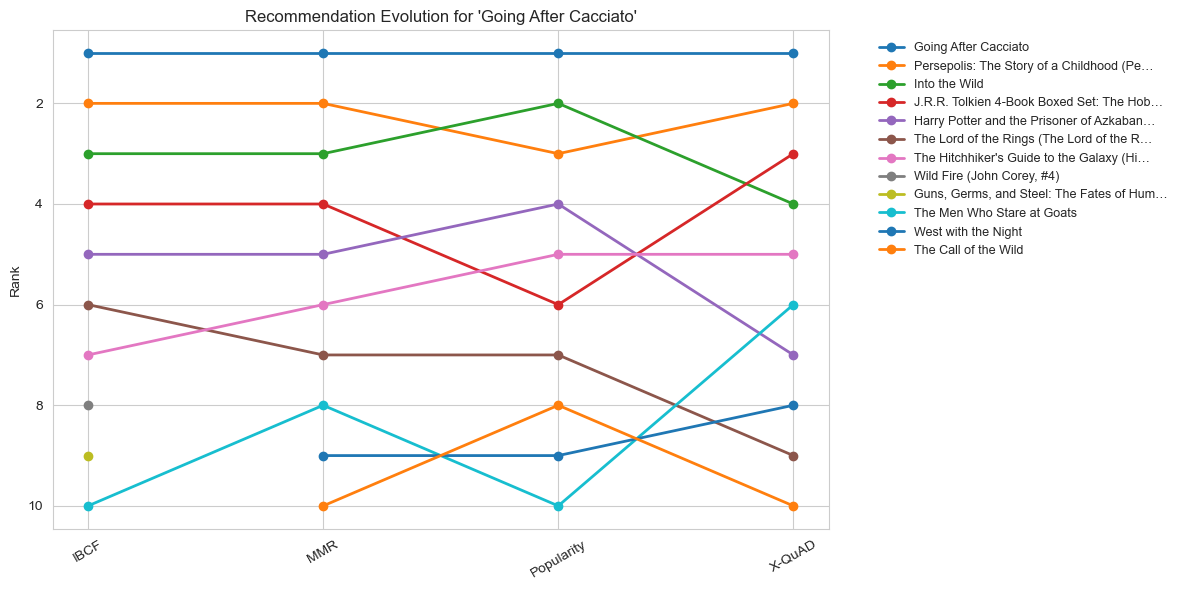

In [45]:
stages = {}  # initializing container for stage DataFrames
if 'ibcf_recs_example' in globals() and isinstance(ibcf_recs_example, pd.DataFrame) and not ibcf_recs_example.empty:  # checking IBCF stage availability
    stages["IBCF"] = ibcf_recs_example  # adding IBCF stage
if 'mmr_recs_example' in globals() and isinstance(mmr_recs_example, pd.DataFrame) and not mmr_recs_example.empty:  # checking MMR stage availability
    stages["MMR"] = mmr_recs_example  # adding MMR stage
if 'pop_recs_example' in globals() and isinstance(pop_recs_example, pd.DataFrame) and not pop_recs_example.empty:  # checking Popularity stage availability
    stages["Popularity"] = pop_recs_example  # adding Popularity stage
if 'final_recs_example' in globals() and isinstance(final_recs_example, pd.DataFrame) and not final_recs_example.empty:  # checking X-QuAD stage availability
    stages["X-QuAD"] = final_recs_example  # adding X-QuAD stage

if not stages:  # verifying that at least one stage exists
    raise RuntimeError(  # raising error if no stages found
        "No stages to plot. Please run Step 8 to create "
        "ibcf_recs_example / mmr_recs_example / pop_recs_example / final_recs_example."
    )

# --- Demo title (safe lookup) ---
_demo_rows = df_model.loc[df_model['book_id'] == example_book_id, 'title']  # selecting title row for demo book
demo_title = _demo_rows.iloc[0] if not _demo_rows.empty else str(example_book_id)  # setting display title with fallback

stage_names = list(stages.keys())  # collecting stage names in order
top_n = 20  # setting number of top items per stage to visualize

# --- Collect the union of top-N book IDs across stages (order-stable) ---
lists_per_stage = []  # initializing list of book lists per stage
for df_stage in stages.values():  # iterating over stages
    s = df_stage.reset_index(drop=True)  # resetting index for safe head selection
    if 'book_id' not in s.columns:  # validating presence of book_id column
        raise KeyError("Expected column 'book_id' in a stage DataFrame.")  # raising error if missing
    lists_per_stage.append(s['book_id'].head(top_n).tolist())  # appending top-N book IDs

seen = set()  # initializing set to track seen book IDs
all_books = []  # initializing ordered list of unique book IDs
for lst in lists_per_stage:  # iterating over stage lists
    for b in lst:  # iterating over book IDs
        if b not in seen:  # checking if book ID is new
            seen.add(b)  # marking book ID as seen
            all_books.append(b)  # appending book ID to union list

# --- Build rank table: rows=book_id, cols=stage, values=rank (1..N) ---
plot_ranks = pd.DataFrame(index=all_books, columns=stage_names, dtype=float)  # initializing rank table
for stage_name, df_stage in stages.items():  # iterating over stages
    s = df_stage.reset_index(drop=True)  # resetting index for ranking
    for rank, book_id in enumerate(s['book_id'].head(top_n), start=1):  # enumerating top-N with ranks
        plot_ranks.at[book_id, stage_name] = float(rank)  # storing rank value

# --- Map ids -> titles safely (with fallback) ---
_title_map = (df_model[['book_id', 'title']]  # selecting ID-title pairs
              .drop_duplicates('book_id')  # dropping duplicate IDs
              .set_index('book_id')['title']  # setting book_id as index and selecting title
              .to_dict())  # converting to dictionary

def short_title(bid, max_len=40):  # defining helper to shorten titles safely
    """Return a short, display-safe title for a book id."""
    t = _title_map.get(bid, str(bid))  # fetching title with fallback to ID
    if isinstance(t, str) and len(t) > max_len:  # checking if title exceeds max length
        return t[:max_len] + '…'  # truncating and appending ellipsis
    return t  # returning title as-is

#  limit number of lines to keep legend readable ---
max_lines = None   # setting optional cap for number of plotted lines
books_to_plot = plot_ranks.index[:max_lines] if isinstance(max_lines, int) else plot_ranks.index  # selecting books to plot

# --- Plot ---
plt.figure(figsize=(12, 6))  # creating figure for rank evolution
for book_id in books_to_plot:  # iterating over selected books
    y = plot_ranks.loc[book_id].values.astype(float)  # extracting rank vector across stages
    # only draw if it appears in at least one stage
    if np.isfinite(y).any():  # checking if book has any finite rank
        label = short_title(book_id)  # creating label with shortened title
        # NaNs break the line automatically where the book doesn't appear
        plt.plot(stage_names, y, marker='o', linewidth=2, label=label)  # plotting rank line across stages

plt.gca().invert_yaxis()  # Rank 1 at the top  # inverting y-axis to place rank 1 at top
plt.xticks(stage_names, rotation=30)  # setting stage names as x-ticks with rotation
plt.ylabel("Rank")  # setting y-axis label
plt.title(f"Recommendation Evolution for '{demo_title}'")  # setting plot title with demo title

# If too many lines, the legend can get crowded—limit via max_lines above
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, frameon=False)  # placing legend outside plot
plt.tight_layout()  # tightening layout for better spacing
plt.show()  # displaying plot
